In [ ]:
# Clean and Select Required Columns
import pandas as pd

df = pd.read_csv("tmdb_5000_movies.csv")

# Select useful columns
df = df[['title','genres','budget','revenue','popularity','runtime','vote_average','vote_count','overview']]

# Remove missing values
df = df.dropna()

df.head()

,title,genres,budget,revenue,popularity,runtime,vote_average,vote_count,overview
0,Avatar,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",237000000,2787965087,150.437577,162.0,7.2,11800,"In the 22nd century, a paraplegic Marine is di..."
1,Pirates of the Caribbean: At World's End,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",300000000,961000000,139.082615,169.0,6.9,4500,"Captain Barbossa, long believed to be dead, ha..."
2,Spectre,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",245000000,880674609,107.376788,148.0,6.3,4466,A cryptic message from Bond’s past sends him o...
3,The Dark Knight Rises,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",250000000,1084939099,112.312950,165.0,7.6,9106,Following the death of District Attorney Harve...
4,John Carter,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",260000000,284139100,43.926995,132.0,6.1,2124,"John Carter is a war-weary, former military ca..."


In [ ]:
# Creating Target Variable
df['success'] = df['revenue'] > df['budget']
df['success'] = df['success'].astype(int)

In [ ]:
# Fixing Genres Column
import ast

def extract_genres(text):
    genres = ast.literal_eval(text)
    return [g['name'] for g in genres]

df['genres'] = df['genres'].apply(extract_genres)

# Take first genre for simplicity
df['main_genre'] = df['genres'].apply(lambda x: x[0] if len(x)>0 else "Unknown")

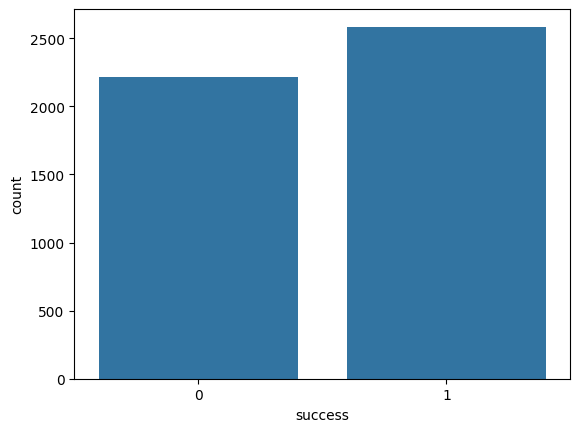

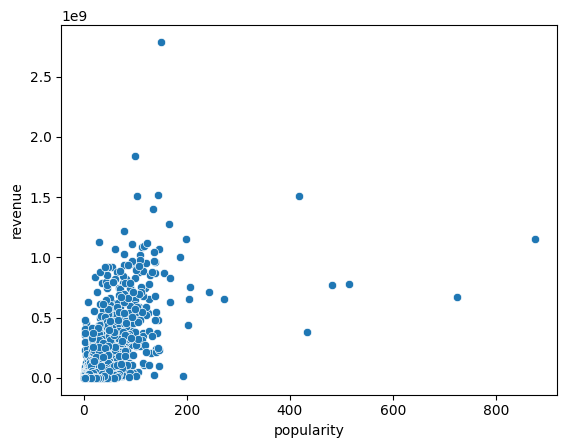

In [ ]:
# Exploratory Analysis
import seaborn as sns
import matplotlib.pyplot as plt

# Success count
sns.countplot(x='success', data=df)
plt.show()

# Popularity vs Revenue
sns.scatterplot(x='popularity', y='revenue', data=df)
plt.show()

In [ ]:
# Sentiment Analysis
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import nltk

nltk.download('vader_lexicon')

sia = SentimentIntensityAnalyzer()

df['sentiment_score'] = df['overview'].apply(lambda x: sia.polarity_scores(x)['compound'])

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [ ]:
# Convert To Labels
def label_sentiment(score):
    if score >= 0.05:
        return "Positive"
    elif score <= -0.05:
        return "Negative"
    else:
        return "Neutral"

df['sentiment'] = df['sentiment_score'].apply(label_sentiment)

In [ ]:
# Genre_wise Sentiment
genre_sentiment = df.groupby('main_genre')['sentiment_score'].mean()
print(genre_sentiment)

main_genre
Action            -0.268839
Adventure         -0.073098
Animation          0.113860
Comedy             0.166371
Crime             -0.388775
Documentary        0.108762
Drama             -0.011264
Family             0.274084
Fantasy           -0.085828
Foreign           -0.811300
History           -0.197368
Horror            -0.480253
Music              0.230121
Mystery           -0.479134
Romance            0.199277
Science Fiction   -0.214996
TV Movie           0.350800
Thriller          -0.332207
Unknown            0.102104
War               -0.309154
Western           -0.227267
Name: sentiment_score, dtype: float64


In [ ]:
# Machine Learning Model
from sklearn.model_selection import train_test_split

X = df[['budget','popularity','runtime','vote_average','vote_count','sentiment_score']]
y = df['success']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [ ]:
# Training the Model
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
# Evalute
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.7864583333333334


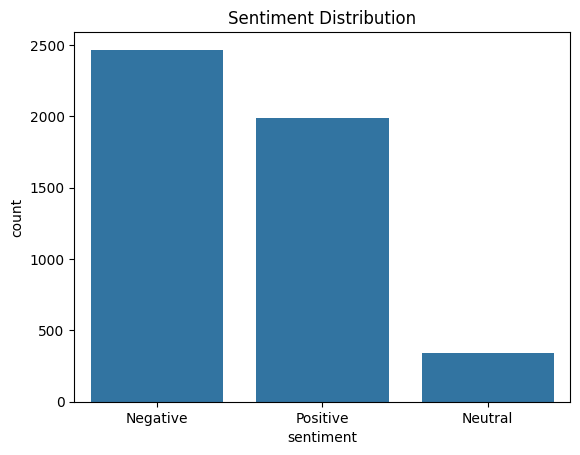

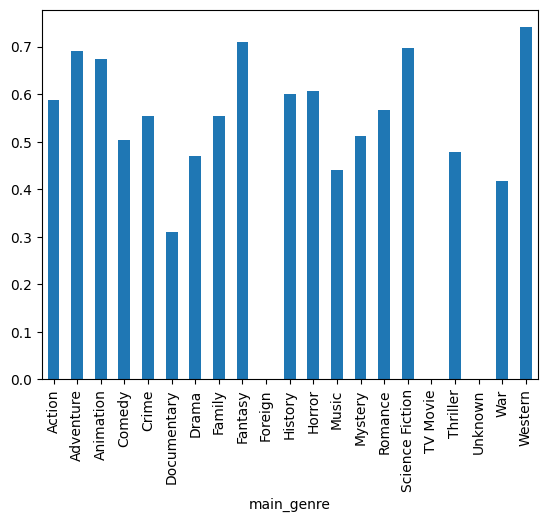

In [ ]:
# Sentiment Distribution
sns.countplot(x='sentiment', data=df)
plt.title("Sentiment Distribution")
plt.show()

# Genre success rate
genre_success = df.groupby('main_genre')['success'].mean()
genre_success.plot(kind='bar')
plt.show()